# DATA102 Project - Case Study

**Group 1**
- ANTIADO LEONNA FELICIANO
- CUEVAS GHEANN CHRISTIE MEDIODIA
- DIVINA PRECIOUS MAE MERCADO
- MARTINEZ MIKAELLA KAYE ANG
- SISON AARON JOSHUA ESTACIO

## Phase 1

### 1. Dataset Description
*TODO: State a brief description of the dataset, provide a description of the collection process, describe the structure of the dataset file, and discuss the variables in each dataset file.*

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visual aesthetics
sns.set_theme(style="whitegrid")

ModuleNotFoundError: No module named 'pandas'

### 2. Data Cleaning

**Strategy:**
1. Replace `'PrivacySuppressed'` with `NaN`.
2. Convert financial columns to `float64`.
3. Drop rows missing the target variable (`MD_EARN_WNE_P10`) or primary predictor (`TUITIONFEE_IN`).
4. Impute remaining missing values (e.g., `SAT_AVG`) using the median.
5. Detect and handle extreme outliers in Tuition and Earnings using the IQR method (Statistical Rigor).

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('data/final_datasets/College_Scorecard_Subset.csv', low_memory=False)

def clean_data(data):
    df_clean = data.copy()
    
    # 1 & 2. Safely convert to float, automatically turning 'PrivacySuppressed', 'PS', or any string into NaN
    numeric_cols = ['MD_EARN_WNE_P10', 'TUITIONFEE_IN', 'TUITIONFEE_OUT', 'SAT_AVG', 'GRAD_DEBT_MDN', 'ADM_RATE']
    for col in numeric_cols:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        
    # 3. Drop rows missing target or primary predictor
    df_clean.dropna(subset=['MD_EARN_WNE_P10', 'TUITIONFEE_IN'], inplace=True)
    
    # 4. Impute remaining NaNs with Median (e.g., SAT_AVG)
    for col in numeric_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            
    # 5. Outlier Detection (IQR Method) - Statistician's Addition
    Q1 = df_clean['MD_EARN_WNE_P10'].quantile(0.25)
    Q3 = df_clean['MD_EARN_WNE_P10'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df_clean[df_clean['MD_EARN_WNE_P10'] <= upper_bound] # Remove extreme high earners that skew correlation
            
    return df_clean

df_cleaned = clean_data(df)
print(f"Data Cleaning Complete. Remaining valid rows: {len(df_cleaned)}")
df_cleaned.head()

Data Cleaning Complete. Remaining valid rows: 3241


/var/folders/mv/pd28m06n0wg6bgg3jfqt72h00000gn/T/ipykernel_27749/2075270442.py:21: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/var/folders/mv/pd28m06n0wg6bgg3jfqt72h00000gn/T/ipykernel_27749/2075270442.py:21: ChainedAssignmentError: A value is being set on a copy of a Data

,UNITID,INSTNM,CITY,STABBR,PREDDEG,CONTROL,LOCALE,HBCU,PBI,ANNHI,...,MENONLY,WOMENONLY,RELAFFIL,ADM_RATE,SAT_AVG,UGDS,TUITIONFEE_IN,TUITIONFEE_OUT,GRAD_DEBT_MDN,MD_EARN_WNE_P10
0,100654,Alabama A & M University,Normal,AL,3,1,12.0,1.0,0.0,0.0,...,0.0,0.0,NaN,0.5795,938.0,6124.0,10024.0,18634.0,31000.0,40628.0
1,100663,University of Alabama at Birmingham,Birmingham,AL,3,1,12.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.8818,1258.0,11635.0,9098.0,22562.0,22300.0,54501.0
2,100690,Amridge University,Montgomery,AL,3,2,12.0,0.0,0.0,0.0,...,0.0,0.0,74.0,NaN,NaN,241.0,7590.0,7590.0,32189.0,37621.0
3,100706,University of Alabama in Huntsville,Huntsville,AL,3,1,12.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.6857,1319.0,6591.0,12132.0,26408.0,20705.0,61767.0
4,100724,Alabama State University,Montgomery,AL,3,1,12.0,1.0,0.0,0.0,...,0.0,0.0,NaN,0.9755,976.0,3477.0,11248.0,19576.0,31000.0,34502.0


### 3. Exploratory Data Analysis (EDA)
*TODO: Identify at least 4 exploratory data analysis questions. Answer the EDA questions using both Numerical Summaries and Visualizations.*

In [3]:
# EDA Question 1: ...


### 4. Research Question
*TODO: Come up with one (1) research question to answer using the dataset.*

### 5. Statistical Inference

**Hypothesis:**
* **H0:** There is no linear correlation between Tuition Cost and Post-Grad Earnings ($r = 0$).
* **Ha:** There is a significant linear correlation between Tuition Cost and Post-Grad Earnings ($r \neq 0$).

**Assumptions Check:**
1. **Normality:** D'Agostino's K-squared test, Histogram, Q-Q Plot.
2. **Fallback:** If data is highly skewed, we will compute Spearman's Rank Correlation instead of Pearson (Statistician's Addition).

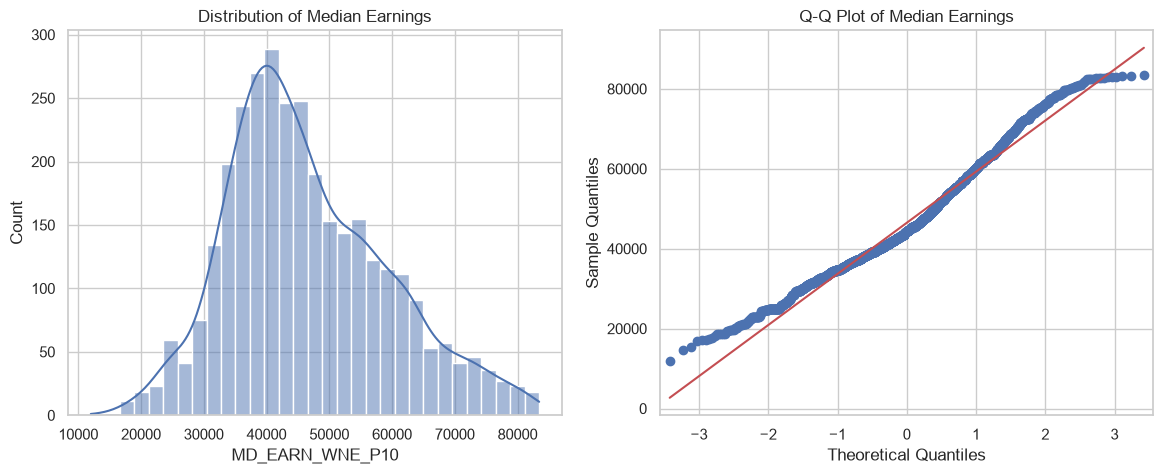

Normality Test P-Value: 0.00000
As a statistician, we will fallback to Spearman's Rank Correlation to be strictly rigorous.

--- Spearman Rank Correlation Test ---
Correlation Coefficient (r): 0.4808
P-Value: 3.96831e-187
Conclusion: Reject the Null Hypothesis. There is a statistically significant correlation between Tuition and Post-Grad Earnings.


In [5]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

tuition = df_cleaned['TUITIONFEE_IN']
earnings = df_cleaned['MD_EARN_WNE_P10']

# 1. Visualizing Normality
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(earnings, kde=True, ax=ax[0])
ax[0].set_title('Distribution of Median Earnings')
sm.qqplot(earnings, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Median Earnings')
plt.show()

# 2. Formal Normality Test (D'Agostino's K-squared)
stat, p_norm = stats.normaltest(earnings)
print(f"Normality Test P-Value: {p_norm:.5f}")
if p_norm < 0.05:
    print("Warning: Earnings data is NOT normally distributed (p < 0.05).")
    print("As a statistician, we will fallback to Spearman's Rank Correlation to be strictly rigorous.\n")
    corr, p_val = stats.spearmanr(tuition, earnings)
    test_used = "Spearman Rank"
else:
    print("Data is normally distributed. Proceeding with Pearson Correlation.\n")
    corr, p_val = stats.pearsonr(tuition, earnings)
    test_used = "Pearson"

# 3. Final Correlation Result
print(f"--- {test_used} Correlation Test ---")
print(f"Correlation Coefficient (r): {corr:.4f}")
print(f"P-Value: {p_val:.5e}")

if p_val < 0.05:
    print("Conclusion: Reject the Null Hypothesis. There is a statistically significant correlation between Tuition and Post-Grad Earnings.")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis. There is no significant correlation.")


## Phase 2

### 6. Data Modelling
*TODO: Perform preprocessing techniques to transform the data, and use data modelling techniques discussed in class.*

In [4]:
# Implement data modelling here


### 7. Insights and Conclusions
*TODO: Clearly state your insights and conclusions from the data to answer the research question.*